# Model: XGBoost
Training a supervised XGBoost classifier on the imbalanced dataset.

In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
import os

sys.path.append(os.path.abspath('..'))

In [2]:
from src.train_xgboost import train_xgboost

# Train the model (uses scale_pos_weight to handle imbalance)
train_xgboost(data_path='../data/processed/train.csv', model_path='../models/xgboost_model.pkl')

Loading training data...
Training XGBoost with scale_pos_weight: 577.29...
Model saved to ../models/xgboost_model.pkl


In [3]:
# Load Test Data
df_test = pd.read_csv('../data/processed/test.csv')
X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

In [4]:
# Load and Evaluate the Model
with open('../models/xgboost_model.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)

print('XGBoost Results:')
print(classification_report(y_test, y_pred))

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.86      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962



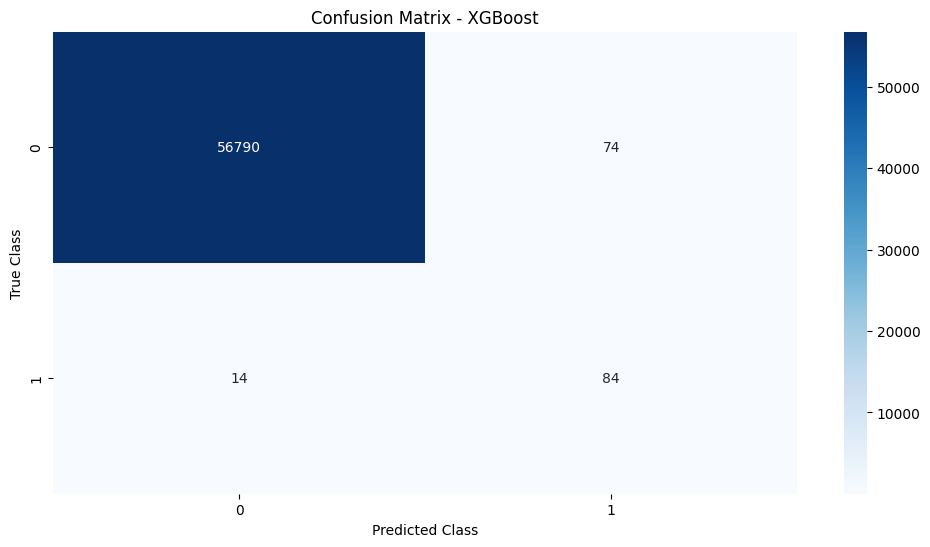

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()